# Deepweeds - MobileNetv3Small

**Subspace FC Layer**
- ReShape Layer (Reshape input tensor to N subspaces)
- Dense Layer (Initial Expansion - feature size expansion to expected out size)
- Dense Layer (Bottleneck Expansion - feature size expansion to double of expected out size)
- Dense Layer (Bottleneck Compression - feature size compressed back to expected out size)

**Ablation study of Subspace FC Layer.**
- "first": Remove first two Dense Layer (Subspace Base Expansion and Bottleneck Expansion) - only use Dense with regularizer and no activation.
- "last" : Remove last two Dense Layer (Bottleneck Expansion and Bottleneck Compression) - only use base expansion Dense with 'ReLU' activation.
- "middle" : Remove second Dense Layer (Bottleneck Expansion) - use Dense with final_out units one with 'ReLU' and one with kernel regularizer.
- "mix" : Mix type 'middle' in single Dense layer - use both 'ReLU' and kernel regularizer in Base Expansion Dense Layer.

In [1]:
import tensorflow as tf
import pandas as pd
import numpy as np
import random
import os
import shutil

tf.__version__

2025-07-30 22:01:29.799762: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-07-30 22:01:29.799887: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-07-30 22:01:29.920479: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


'2.15.0'

# Configurations

In [2]:
INFERENCE_DEVICE = 'GPU:0' if len(tf.config.list_physical_devices('GPU')) else 'CPU:0'

################################
###### Configurations #########
##############################
seed = 999
SEED = seed
USE_DETERMINISTIC = True
K_FOLD_INDEX = 1
oversampling = 0 # How many times are we gonna over sample

## Subspace_Bottleneck_FCLayer Config
NUM_SPACES = 16
FINAL_FEAT_SIZE = 1024
ABLATION = 'use_relu' ## 'first', 'middle', 'last', 'mix', or None

## Model Configurations
MODEL_NAME=f"MobileNetV3Small_KF{K_FOLD_INDEX+1}.keras"
IMG_SIZE=(224,224,3)

## Training Configurations
TRAIN_BATCH_SIZE=32
EPOCHS = 300
ES_PATIENCE = 16 ## Patience Epoch for Early Stopping
ES_MONITOR = 'val_loss'
LR_REDUCTION_FACTOR = 0.8 ## for ReduceLROnPlateau Callback
LR_REDUCTION_PATIENCE = 3 ## Patience for LR Reduction
LR_REDUCTION_MONITOR = 'val_loss'

##### FineTuning Part
INIT_LR1 = 2e-4 ## Initial Learning Rate (AdamW) 
W_DECAY1 = 5e-2 ## Weight Decay
MIN_LR1 = 1e-7 ## Minimum Learning Rate for ReduceLROnPlateau Callback
##
USE_WARMUP = False
WARMUP_EPOCHS = 5
WARMUP_INIT_LR = INIT_LR1 / WARMUP_EPOCHS
WARMUP_MAX_LR = INIT_LR1
WARMUP_INCREMENT_RATE = 0.3

##### After Base Model Freezing and Appending Subspace FC Layer. Training only FC Layer.
INIT_LR2 = 2e-6 # Initial Learning Rate for optimizer (AdamW)
W_DECAY2 = 5e-4 ## Weight Decay for optimizer
MIN_LR2 = 1e-9 # Minimum Learning Rate for ReduceLROnPlateau

#### -- Optimizer
USE_ADAMW = '2.15' in tf.__version__
#########################################
isKaggle = 'kaggle' in os.getcwd()

if isKaggle:
    DATASET_PATH = "/kaggle/input/deepweeds"
    IMAGE_DATASET_PATH = "/kaggle/input/deepweeds/images" ## For Kaggle
    DATASET_OUTPUT_PATH = "/kaggle/working/deepweeds_9c" ## For Kaggle
else:
    try:
        DATASET_PATH = reganmaharjan_deepweeds_path
        DATASET_OUTPUT_PATH = '/content/dataset_9c' ## For GoogleColab
        IMAGE_DATASET_PATH = reganmaharjan_deepweeds_path + '/images' ## For GoogleColab
    except:
        DATASET_PATH = ''
        IMAGE_DATASET_PATH = '' ## Assign The Image Path
        DATASET_OUTPUT_PATH = '' ## Assign The path where the Images are to ogranized for Data Generator from Directory


isTPU = False
fixDatasetBatch = False ## if True: duplicates files randomly such that each batch contains same no.of files - Required when isTPU=True.

In [3]:
print("Tensorflow version " + tf.__version__)
if tf.config.list_logical_devices('TPU'):
    if isKaggle:
        # On TPU VMs use this line instead:
        resolver = tf.distribute.cluster_resolver.TPUClusterResolver(tpu="local")  ## if kaggle
    else:        
        resolver = tf.distribute.cluster_resolver.TPUClusterResolver() ## if colab

    tf.config.experimental_connect_to_cluster(resolver)
    tf.tpu.experimental.initialize_tpu_system(resolver)

    #---------
    strategy = tf.distribute.TPUStrategy(resolver)
    print('TPU available')
    isTPU = True
else: ### If GPU or CPU
    if tf.config.list_logical_devices('GPU'): 
        print('GPU available')
    else:
        print("Only CPU available")
       
    # For testing without a TPU use this line instead: 
    # strategy = tf.distribute.OneDeviceStrategy("/cpu:0")
    strategy = tf.distribute.MirroredStrategy()


print("REPLICAS: ", strategy.num_replicas_in_sync)
if isTPU:
    USE_ADAMW = False
    LR_REDUCTION_PATIENCE = 5
    ES_PATIENCE = 27
    print("Use ADAM with TPU")

Tensorflow version 2.15.0
GPU available
REPLICAS:  1


In [4]:
def seedEverything(seed=42, deterministic = False):
    tf.random.set_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    
    tf.keras.utils.set_random_seed(seed)
    
    if deterministic:
        tf.config.experimental.enable_op_determinism()
        
        os.environ['TF_DETERMINISTIC_OPS'] = '1'
        os.environ['TF_CUDNN_DETERMINISTIC'] = '1'

        #tf.config.threading.set_inter_op_parallelism_threads(1)
        #tf.config.threading.set_intra_op_parallelism_threads(1)


seedEverything(SEED, USE_DETERMINISTIC)
tf.config.set_soft_device_placement(True)

In [5]:
## Downloading DeepWeeds Data  ## For Google Colab
# url = 'https://drive.google.com/uc?export=download&id=1xnK3B6K6KekDI55vwJ0vnc2IGoDga9cj'
# !gdown 1xnK3B6K6KekDI55vwJ0vnc2IGoDga9cj
# !unzip -qq images.zip -d images

In [6]:
try:
    data_info = pd.read_csv(f"{DATASET_PATH}/labels.csv") ## For Kaggle
except:
    data_info = pd.read_csv('https://raw.githubusercontent.com/AlexOlsen/DeepWeeds/master/labels/labels.csv') ## for GoogleColab
data_info

,Filename,Label,Species
0,20160928-140314-0.jpg,0,Chinee apple
1,20160928-140337-0.jpg,0,Chinee apple
2,20160928-140731-0.jpg,0,Chinee apple
3,20160928-140747-0.jpg,0,Chinee apple
4,20160928-141107-0.jpg,0,Chinee apple
...,...,...,...
17504,20180322-133822-1.jpg,8,Negative
17505,20180322-133832-1.jpg,8,Negative
17506,20180322-133840-1.jpg,8,Negative
17507,20180322-133850-1.jpg,8,Negative


In [7]:
data_info[['Species','Label']].groupby(by='Species').count().T

Species,Chinee apple,Lantana,Negative,Parkinsonia,Parthenium,Prickly acacia,Rubber vine,Siam weed,Snake weed
Label,1125,1064,9106,1031,1022,1062,1009,1074,1016


In [8]:
label2id = data_info[['Species','Label']].groupby(by='Species').min().to_dict()['Label']
id2label = {label2id[i]:i for i in label2id}
id2label

{0: 'Chinee apple',
 1: 'Lantana',
 8: 'Negative',
 2: 'Parkinsonia',
 3: 'Parthenium',
 4: 'Prickly acacia',
 5: 'Rubber vine',
 6: 'Siam weed',
 7: 'Snake weed'}

In [9]:
low_data_labels = data_info[data_info['Species'] != "Negative"]['Label'].unique() ## labels with very low data
low_data_labels

array([0, 1, 7, 6, 4, 3, 5, 2])

# Splitting Data into Train:Valid:Test Splits (60:20:20)

In [10]:
# colabAI prompt: train test split using data_info
from sklearn.model_selection import train_test_split, StratifiedKFold

### K-Fold Validation-----
#####---------------------
split_index = K_FOLD_INDEX # index to retrieve
print("Using KFold: Index",split_index+1,"out of 5 folds")
print("-------------------------------------------------\n")

# skfold = StratifiedKFold()
# kSplits = skfold.split(data_info['Filename'], y=data_info['Label'])

# for index in range(skfold.get_n_splits()):
#     train_index, test_index = next(kSplits)
#     if index == split_index:
#         break

# trax, tex, tray, tey = train_test_split(data_info['Filename'],data_info['Label'], test_size=0.4, random_state=seed)
# train_data = pd.DataFrame({"Filename":trax,"label":tray})

# trax, tex, tray, tey = train_test_split(tex,tey, test_size=0.5, random_state=seed)
# valid_data = pd.DataFrame({"Filename":trax,"label":tray})
# test_data = pd.DataFrame({"Filename":tex,"label":tey})

Using KFold: Index 2 out of 5 folds
-------------------------------------------------



In [11]:
## Using Folds Used in The DeepWeeds Paper
try:
    train_data = pd.read_csv(f'{DATASET_PATH}/train_subset{K_FOLD_INDEX}.csv')
    valid_data = pd.read_csv(f'{DATASET_PATH}/val_subset{K_FOLD_INDEX}.csv')
    test_data = pd.read_csv(f'{DATASET_PATH}/test_subset{K_FOLD_INDEX}.csv')

except:
    train_data = pd.read_csv('https://raw.githubusercontent.com/AlexOlsen/DeepWeeds/master/labels/train_subset{}.csv'.format(split_index)) ## for GoogleColab
    valid_data = pd.read_csv('https://raw.githubusercontent.com/AlexOlsen/DeepWeeds/master/labels/val_subset{}.csv'.format(split_index)) ## for GoogleColab
    test_data = pd.read_csv('https://raw.githubusercontent.com/AlexOlsen/DeepWeeds/master/labels/test_subset{}.csv'.format(split_index)) ## for GoogleColab

train_data.rename(columns={"Label":"label"}, inplace=True)
valid_data.rename(columns={"Label":"label"}, inplace=True)
test_data.rename(columns={"Label":"label"}, inplace=True)

print("Is There Duplicates: ", not valid_data[valid_data['Filename'].isin(test_data['Filename'])].empty)
print("Train Data\n--------\n",train_data.groupby(by='label').count().T, "\tTotal:", train_data.shape)
print("Validation Data\n--------\n",valid_data.groupby(by='label').count().T, "\tTotal:", valid_data.shape)
print("Test Data\n--------\n",test_data.groupby(by='label').count().T, "\tTotal:", test_data.shape)

Is There Duplicates:  False
Train Data
--------
 label       0    1    2    3    4    5    6    7     8
Filename  676  637  619  613  637  605  644  610  5463 	Total: (10504, 2)
Validation Data
--------
 label       0    1    2    3    4    5    6    7     8
Filename  225  213  206  204  212  202  215  203  1822 	Total: (3502, 2)
Test Data
--------
 label       0    1    2    3    4    5    6    7     8
Filename  225  213  206  205  213  202  215  203  1821 	Total: (3503, 2)


# Helper Functions

- Organize Images to Directory as per Label for Creating Generator (organize_data_to_directory)
- Dataset Generator (getDatasetGenerators) - works in tandem with "organize_data_to_directory"
- Class Weights For Imbalanced Dataset (getWeightedClass)
- Accuracy / Loss plot (plot_loss_acc)
- Evaluation Metrics Calculation (eval_model, print_stats, calcFalseRate)
- Prediction with Threshold as used by DeepWeeds Author (prediction_argmax)



In [12]:
from tqdm.auto import tqdm

def organize_data_to_directory(data_info,source_dir='',target_dir='',oversample=0, oversampling_labels=[]):
    indices=[]
    if fixDatasetBatch or isTPU:
        batch = TRAIN_BATCH_SIZE * strategy.num_replicas_in_sync
        size = data_info.shape[0]
        remainder = size % batch
        residue = batch - remainder
        rng = np.arange(size)
        np.random.shuffle(rng)
        indices = rng[:residue]
        
    for index, row in tqdm(data_info.iterrows()):
        filename = row['Filename']
        label = row['label']

        source = os.path.join(source_dir,filename)

        #if not os.path.exists(source):
        #    print("File Doesn't Exist", source)
        #    continue

        target_path = os.path.join(target_dir,str(label))
        target = os.path.join(target_path,filename)
        # print(source,target)

        if not os.path.exists(target_path):
            os.mkdir(target_path)

        if not os.path.exists(target):
            if oversample and (label in oversampling_labels):
                for i in range(oversample):
                    sample_filename = os.path.join(target_path, "oversample-"+str(i)+"-"+filename)
                    shutil.copy(source, sample_filename)
            elif index in indices:
                sample_filename = os.path.join(target_path, f"last_batch_fix_{index}-"+filename)
                shutil.copy(source, sample_filename)
                
            shutil.copy(source,target)

##-----------------------------
###----------------------------

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import image_dataset_from_directory

def getDatasetGenerators(train_dir, **kwargs):
    # --------------------
    # Flow training images in batches using generator
    # --------------------
    generator = image_dataset_from_directory(
        train_dir,
        **kwargs
    )

    return generator

In [13]:
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
import math

def prediction_argmax(prediction, rand_guess=1):
    prediction = np.asarray(prediction)
    l_pred = np.argmax(prediction[low_data_labels])
    if(prediction[l_pred] > rand_guess):
        return l_pred

    return np.argmax(prediction)

def calcFalsePositiveRate(a_label, p_label, label_names=None, n_class=None):
    if n_class is None:
        n_class = len(np.unique(a_label))
    conf_mat = tf.math.confusion_matrix(a_label, p_label, num_classes=n_class).numpy()

    false_rate = []
    total = len(a_label)
    for i in range(n_class):
        tP = conf_mat[i][i]
        fN = np.sum(conf_mat[i,:]) - tP

        fP = np.sum(conf_mat[:,i]) - tP
        tN = total - (tP + fN + fP)

        fP_Rate = fP/(tN+fP)
        # fN_Rate = fN/(tP+fN)
        accuracy = tP / (tP+fN)

        false_rate.append((fP_Rate,accuracy))

    false_rate = pd.DataFrame(false_rate, columns=["False Positive Rate", "Accuracy"], index=label_names)
    return false_rate

def printStats(actual_labels,prediction, use_rand_guess= 0):
    if use_rand_guess:
        prediction = [prediction_argmax(x, rand_guess=use_rand_guess) for x in prediction]
    else:
        prediction = [np.argmax(x) for x in prediction]

    print("Evaluation Metrics\n=================================\n")
    #     print("F1-Score",f1_score(actual_labels,prediction,average='weighted'))
    #     print("Precision-Score",precision_score(actual_labels,prediction,average='weighted'))
    #     print("Recall-Score",recall_score(actual_labels,prediction,average='weighted'))
    #     print("accuracy_Score",accuracy_score(actual_labels,prediction))

    label_names = [id2label[i] for i in range(len(id2label))]
    print(classification_report(actual_labels, prediction,digits=5, target_names=label_names))
    print()
    print(calcFalsePositiveRate(actual_labels, prediction, label_names = label_names))
    print()
    print("Confusion Matrix\n=================================\n")
    n_class = np.unique(actual_labels).shape[0]
    cmd = ConfusionMatrixDisplay.from_predictions(
        actual_labels, prediction,
        display_labels=label_names,
        xticks_rotation=45 #'vertical'
    )
    #cmd.plot()
    plt.show()

def eval_model(model, data_gen, use_rand_guess=False):
    print("model.evaluate")
    model.evaluate(data_gen)

    print("model.predict")
    actual_labels = []
    pred_prob = []
    for batch in tqdm(data_gen):
        actual_labels.extend([np.argmax(z) for z in batch[1]])
        pred_prob.extend(list(model(batch[0], training=False)))

    printStats(actual_labels,pred_prob,use_rand_guess)
    return actual_labels, pred_prob


def plot_loss_acc(history):
    '''Plots the training and validation loss and accuracy from a history object'''
    acc = [0.0 if math.isnan(v) else v for v in history['accuracy']]
    val_acc = [0.0 if math.isnan(v) else v for v in history['val_accuracy']]
    loss = [0.0 if math.isnan(v) else v for v in history['loss']]
    val_loss = [0.0 if math.isnan(v) else v for v in history['val_loss']]
    
    if 'peaks' in history:
        peaks = history['peaks']
    else:
        _min = np.argmin(val_loss)
        peaks = [_min]

    epochs = range(len(acc))
    print("Total Epochs:",epochs)

    plt.figure(figsize=[16, 4])
    plt.subplot(1,2,1)
    p_value = [val_acc[p] for p in peaks]
    plt.scatter(peaks, p_value, marker='o',s=50)
    plt.plot(epochs, acc, label='Training accuracy', color='red')
    plt.plot(epochs, val_acc, label='Validation accuracy', color='magenta')
    plt.title('Training and validation accuracy')
    plt.legend()

    plt.subplot(1,2,2)
    p_value = [val_loss[p] for p in peaks]
    plt.scatter(peaks, p_value, marker='o',s=50)
    plt.plot(epochs, loss, label='Training Loss', color='red')
    plt.plot(epochs, val_loss, label='Validation Loss', color='magenta')
    plt.title('Training and validation loss')
    plt.legend()

    plt.show()

# Creating Dateset ImageGenerator

In [14]:
if oversampling:
    print("Oversampling training set",oversampling,"times for labels",low_data_labels)
else:
    print("No OverSampling")

input_dir = IMAGE_DATASET_PATH
base_dir = DATASET_OUTPUT_PATH

train_dir = os.path.join(base_dir, 'train')
validation_dir = os.path.join(base_dir, 'validation')
test_dir = os.path.join(base_dir, 'test')

if os.path.exists(base_dir):
    shutil.rmtree(base_dir)

os.mkdir(base_dir)
os.mkdir(train_dir)
os.mkdir(validation_dir)
os.mkdir(test_dir)

## Organizing Training Data
organize_data_to_directory(train_data, source_dir=input_dir, target_dir=train_dir, oversample=oversampling, oversampling_labels=low_data_labels)

# ## Organizing Validation Data
organize_data_to_directory(valid_data, source_dir=input_dir, target_dir=validation_dir)

# ## Organizing Test Data
organize_data_to_directory(test_data, source_dir=input_dir, target_dir=test_dir)

No OverSampling


0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

In [15]:
train_generator = getDatasetGenerators(
      train_dir,
      batch_size=TRAIN_BATCH_SIZE,
      label_mode='categorical',
      image_size = IMG_SIZE[:2],
      shuffle=True
)

validation_generator = getDatasetGenerators(
      validation_dir,
      batch_size=TRAIN_BATCH_SIZE,
      label_mode='categorical',
      image_size = IMG_SIZE[:2],
      shuffle=True
)

test_generator = getDatasetGenerators(
      test_dir,
      batch_size=TRAIN_BATCH_SIZE,
      label_mode='categorical',
      image_size = IMG_SIZE[:2],
      shuffle=False
)

with strategy.scope(): 
    if isTPU:  
        train_generator = train_generator.rebatch(TRAIN_BATCH_SIZE * strategy.num_replicas_in_sync, drop_remainder=True)
        validation_generator = validation_generator.rebatch(TRAIN_BATCH_SIZE * strategy.num_replicas_in_sync, drop_remainder=True)
        test_generator = test_generator.rebatch(TRAIN_BATCH_SIZE * strategy.num_replicas_in_sync, drop_remainder=True)
        
    train_generator = train_generator.prefetch(tf.data.AUTOTUNE)
    validation_generator = validation_generator.prefetch(tf.data.AUTOTUNE)
    test_generator = test_generator.prefetch(tf.data.AUTOTUNE)     

Found 10504 files belonging to 9 classes.
Found 3502 files belonging to 9 classes.
Found 3503 files belonging to 9 classes.


# Sample Images

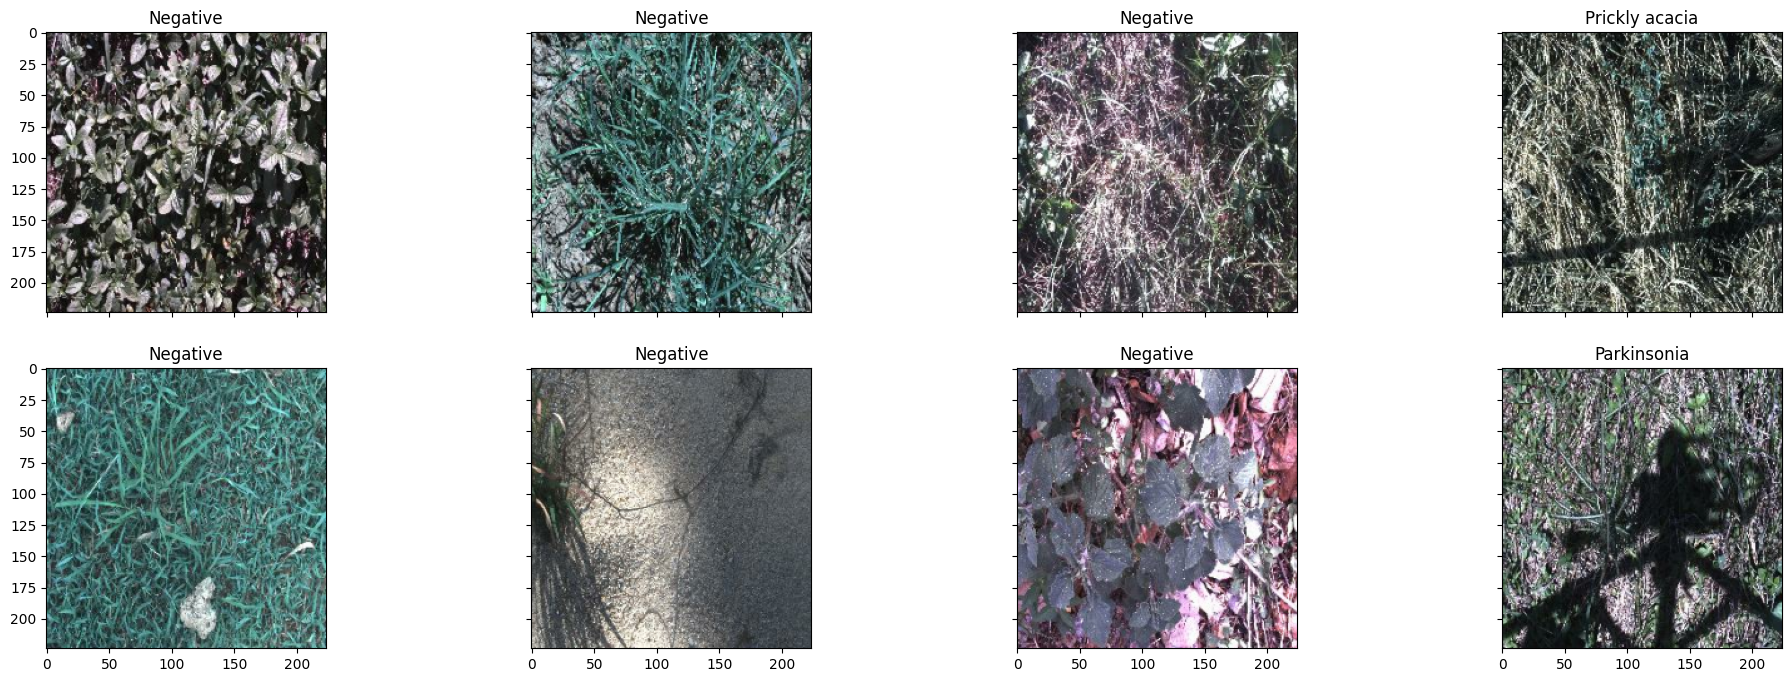

In [16]:
#image visualization
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2, 4, sharex=True, sharey=True, figsize=(24,8))

for images, labels in validation_generator:
    for i in range(2):
        for j in range(4):
            ax[i][j].imshow(images[i+j*2].numpy().astype(np.int32))
            ax[i][j].set_title(id2label[np.argmax(labels[i+j*2])])

    break
plt.show()

In [17]:
import tensorflow as tf
import tensorflow.keras as keras
import tensorflow.keras.layers as layers
from tensorflow.keras.layers import GlobalAveragePooling2D, GlobalMaxPooling2D, MaxPool2D, Reshape, \
                        Dense, multiply, Permute, Concatenate, Conv2D, Add, Activation, Lambda, Average
from tensorflow.keras import backend as K
from tensorflow.keras.activations import sigmoid, softmax


def GlobalAverageOfMaximums(x, max_pool_size=2, layer_num=1, keep_out_dims=False):
    _max = layers.MaxPooling2D(pool_size=max_pool_size,padding='same', name="Maximums_L{}".format(layer_num))(x)
    _avg = layers.GlobalAveragePooling2D(name="Average_of_Maximums_L{}".format(layer_num), keepdims=keep_out_dims)(_max)
    return _avg

# Building MobileNet Model

In [18]:
from tensorflow.keras.applications import MobileNet, MobileNetV2, MobileNetV3Small, MobileNetV3Large
from tensorflow.keras.applications import EfficientNetV2S, ConvNeXtSmall

def augment(seed=42):
    augs = [] if isTPU else [layers.RandomRotation(0.5, seed=seed, name='RR_Rot'), 
                            layers.RandomTranslation(0.4, 0.4, seed=seed, name='RR_Trans'),
                            layers.RandomZoom(0.2, 0.2, seed=seed, name='RR_Zoom'),] ## can't run with TPU
    
    aug_model = keras.Sequential([
        layers.Input(IMG_SIZE),
        layers.RandomBrightness(0.3, (0, 1),seed=seed, name='RR_Bright'),
        # layers.RandomContrast(0.3, seed=seed, name='RR_Contr'), # can't run deterministically
        layers.RandomFlip(seed=seed, name='RR_Flip'),
        *augs,
        layers.GaussianNoise(0.01, seed=SEED, name='RR_GNoise'),
        # layers.GaussianDropout(0.01, seed=seed, name='RR_Gauss'),
    ], name='augment_pipeline')
    aug_model.summary()
    
    return aug_model


def skipAugment(model):
    inputs = keras.Input(shape=IMG_SIZE)
    x = inputs
    for layer in model.layers:
        if 'augment' not in layer.name and 'input' not in layer.name:
            x = layer(x)

    model = keras.Model(inputs=inputs, outputs=x, name=model.name)
    return model


def hard_sigmoid(x):
    relu6 = layers.ReLU(max_value=6)
    return relu6(x + 3) / 6
    
def hard_swish(x):
    return x * hard_sigmoid(x)

def MobilenetV3Base(img_size):
    # Load the MobileNet model with weights pre-trained on ImageNet.
    mobilenet = MobileNetV3Small(input_shape=img_size, weights='imagenet', include_preprocessing=False)
    mobilenet.trainable = True

    base_index = 0
    for i in range(len(mobilenet.layers)):
        if('global_average_pooling2d' in mobilenet.layers[i].name):
            base_index = i
            break
            
    out_layer = mobilenet.layers[base_index-1]
    base_model =  keras.Model(inputs=mobilenet.layers[0].output, outputs=out_layer.output, name = mobilenet.name+"_base_")
    base_model.trainable = True
    
    pi0 = base_index+1 # pooler index start
    pi1 = base_index+1 # pooler index end
    for i in range(base_index, len(mobilenet.layers)):
        if('conv' in mobilenet.layers[i].name):
            pi1 = i
            break
    
    FCLayer = keras.Model(inputs=mobilenet.layers[pi0].input, outputs=mobilenet.layers[pi1].output, name="MobileNet-FCLayer")
    
    return base_model , FCLayer

def subSpaceBottleneckFCLayer(in_shape, n_spaces = 8, out_feat_size = 1024):
    final_out = out_feat_size // n_spaces
    interm_out = final_out*2

    if ABLATION == 'first':
        bottleneck_layer = keras.Sequential([
            layers.Input(in_shape),
            layers.Reshape((n_spaces, -1), name="SubspaceFC_Reshape"),
            layers.Dense(final_out, use_bias=False, kernel_regularizer=keras.regularizers.L1L2(0.01,0.01), name="SubspaceFC_Bottleneck_Compress"),
            layers.Dropout(0.3, seed=SEED, name="SubspaceFC_Dropout")
        ], name='Subspace_Bottleneck_FCLayer')

    elif ABLATION == 'last':
        bottleneck_layer = keras.Sequential([
            layers.Input(in_shape),
            layers.Reshape((n_spaces, -1), name="SubspaceFC_Reshape"),
            layers.Dense(final_out, activation='relu', use_bias=False, kernel_initializer=keras.initializers.HeUniform(seed), name="SubspaceFC_Base"),
            layers.Dropout(0.3, seed=SEED, name="SubspaceFC_Dropout")
        ], name='Subspace_Bottleneck_FCLayer')

    elif ABLATION == 'middle':
        bottleneck_layer = keras.Sequential([
            layers.Input(in_shape),
            layers.Reshape((n_spaces, -1), name="SubspaceFC_Reshape"),
            layers.Dense(final_out, activation='relu', use_bias=False, kernel_initializer=keras.initializers.HeUniform(seed), name="SubspaceFC_Base"),
            layers.Dense(final_out, use_bias=False, kernel_regularizer=keras.regularizers.L1L2(0.01,0.01), name="SubspaceFC_Bottleneck_Compress"),
            layers.Dropout(0.3, seed=SEED, name="SubspaceFC_Dropout")
        ], name='Subspace_Bottleneck_FCLayer')
        
    elif ABLATION == 'mix':
        bottleneck_layer = keras.Sequential([
            layers.Input(in_shape),
            layers.Reshape((n_spaces, -1), name="SubspaceFC_Reshape"),
            layers.Dense(final_out, activation='relu', use_bias=False, kernel_initializer=keras.initializers.HeUniform(seed), kernel_regularizer=keras.regularizers.L1L2(0.01,0.01), name="SubspaceFC_Base"),
            layers.Dropout(0.3, seed=SEED, name="SubspaceFC_Dropout")
        ], name='Subspace_Bottleneck_FCLayer')
        

    else:
        activation = 'relu' if ABLATION == 'use_relu' else None
        bottleneck_layer = keras.Sequential([
            layers.Input(in_shape),
            layers.Reshape((n_spaces, -1), name="SubspaceFC_Reshape"),
            layers.Dense(final_out, activation='relu', use_bias=False, kernel_initializer=keras.initializers.HeUniform(seed), name="SubspaceFC_Base"),
            layers.Dense(interm_out, activation='relu', use_bias=False, kernel_initializer=keras.initializers.HeUniform(seed), name="SubspaceFC_Bottleneck_Expand"),
            layers.Dense(final_out, use_bias=False, activation=activation, kernel_regularizer=keras.regularizers.L1L2(0.01,0.01), name="SubspaceFC_Bottleneck_Compress"),
            layers.Dropout(0.3, seed=SEED, name="SubspaceFC_Dropout")
        ], name='Subspace_Bottleneck_FCLayer')
    bottleneck_layer.summary()
    
    return bottleneck_layer
    

def buildModel(IMG_SIZE, fusion_type='average', cbam_order='normal', skip_preprocess=False):
    # Load the MobileNet model with weights pre-trained on ImageNet.
    base_model, FCLayer = MobilenetV3Base(IMG_SIZE)
    base_model.trainable = True
    FCLayer.trainable = True
    # out_dim = 1024 if "small" in base_model.name.lower() else 1280 if "large" in base_model.name.lower() else base_model.output.shape[-1]

    print("Base Model:", base_model.name)
    print(len(base_model.layers))

    ####----------------------------------------------
    # Define the input layer.
    inputs = keras.Input(shape=IMG_SIZE, name='input')
    x = inputs

    # Pre-process the input.
    if not skip_preprocess:
        x = layers.Resizing(IMG_SIZE[0], IMG_SIZE[1], name='PP_Resize')(x)
        x = layers.Rescaling(1./255, name='PP_Rescale_down')(x)
    
        x = augment(seed)(x)
    else:
        x = inputs
    
    x = base_model(x, training=True)
    x = layers.Dropout(0.3, seed=SEED)(x) 
    
    x = layers.GlobalAveragePooling2D(keepdims=True)(x)
    
    bottleneck = subSpaceBottleneckFCLayer(x.shape[1:], NUM_SPACES, FINAL_FEAT_SIZE)
    x = bottleneck(x)
    
    x = layers.Flatten()(x)
    outputs = layers.Dense(9, activation='softmax', name='classifier')(x)
    model_name = "DeepWeeds-" + base_model.name
    
    # Create the model.
    model = keras.Model(inputs=inputs, outputs=outputs, name=model_name)
    return model

In [19]:
with strategy.scope():
    model = buildModel(IMG_SIZE)
model.summary()

10734624/10734624 [==============================] - 0s 0us/step
Base Model: MobilenetV3small_base_
228
Model: "augment_pipeline"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 RR_Bright (RandomBrightnes  (None, 224, 224, 3)       0         
 s)                                                              
                                                                 
 RR_Flip (RandomFlip)        (None, 224, 224, 3)       0         
                                                                 
 RR_Rot (RandomRotation)     (None, 224, 224, 3)       0         
                                                                 
 RR_Trans (RandomTranslatio  (None, 224, 224, 3)       0         
 n)                                                              
                                                                 
 RR_Zoom (RandomZoom)        (None, 224, 224, 3)       0         
            

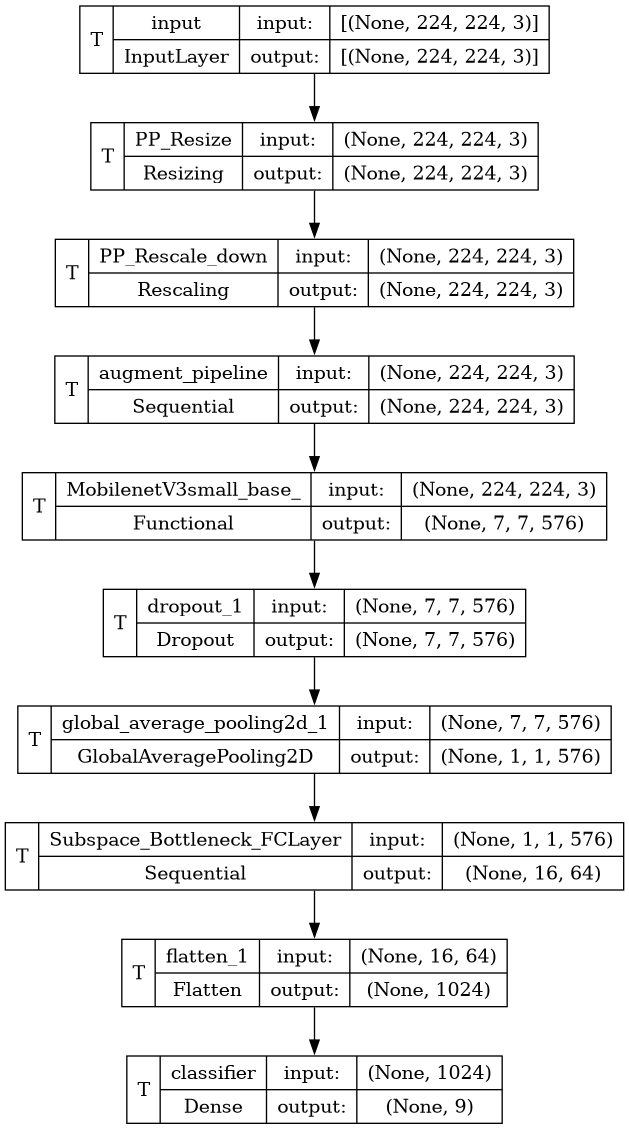

In [20]:
tf.keras.utils.plot_model(model, show_trainable=True, show_layer_names=True, show_shapes=True)

# Trial 1 - FineTuning

In [21]:
from tensorflow.keras.optimizers import Adam, AdamW

checkpoint = tf.keras.callbacks.ModelCheckpoint(f"base_{MODEL_NAME}", save_best_only=True, monitor=ES_MONITOR)
with strategy.scope():
    loss = tf.keras.losses.CategoricalFocalCrossentropy()
    optimizer = Adam(learning_rate=(WARMUP_INIT_LR if USE_WARMUP else INIT_LR1),  weight_decay=W_DECAY1, clipnorm=1.0) if not USE_ADAMW else AdamW(learning_rate=(WARMUP_INIT_LR if USE_WARMUP else INIT_LR1),  weight_decay=W_DECAY1)
    metrics = [] if isTPU else ['accuracy'] 
    model.compile(loss=loss,
              optimizer=optimizer,
              metrics=metrics)

    early_stopping = tf.keras.callbacks.EarlyStopping(monitor=ES_MONITOR, patience=ES_PATIENCE, verbose=1, restore_best_weights=True)
    reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss',factor=LR_REDUCTION_FACTOR, patience=LR_REDUCTION_PATIENCE, verbose=1, min_lr=MIN_LR1)

    def createWarmUpScheduler(epochs=5, inc_rate=0.5, init_lr=2e-6, final_lr=2e-5):
        def scheduler(e, lr):
            if e < epochs:
                new_lr =  lr + (lr * inc_rate)
                return new_lr if new_lr < final_lr else final_lr
            elif e == epochs:
                return final_lr
            else:
                return lr

        return scheduler
        
    warmup = keras.callbacks.LearningRateScheduler(createWarmUpScheduler(WARMUP_EPOCHS, WARMUP_INCREMENT_RATE, WARMUP_INIT_LR, INIT_LR1))

    callbacks = [checkpoint, early_stopping, reduce_lr] + ([warmup] if USE_WARMUP else [])
    print(len(callbacks))

print(model.optimizer.get_config())

3
{'name': 'AdamW', 'weight_decay': 0.05, 'clipnorm': None, 'global_clipnorm': None, 'clipvalue': None, 'use_ema': False, 'ema_momentum': 0.99, 'ema_overwrite_frequency': None, 'jit_compile': True, 'is_legacy_optimizer': False, 'learning_rate': 0.0002, 'beta_1': 0.9, 'beta_2': 0.999, 'epsilon': 1e-07, 'amsgrad': False}


Epoch 1/300


2025-07-30 22:03:17.415778: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inDeepWeeds-MobilenetV3small_base_/dropout_1/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1753913002.876805      66 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


329/329 [==============================] - 56s 80ms/step - loss: 5.7723 - accuracy: 0.5496 - val_loss: 3.4688 - val_accuracy: 0.6728 - lr: 2.0000e-04
Epoch 2/300
329/329 [==============================] - 24s 71ms/step - loss: 2.0439 - accuracy: 0.6558 - val_loss: 0.9006 - val_accuracy: 0.7433 - lr: 2.0000e-04
Epoch 3/300
329/329 [==============================] - 24s 72ms/step - loss: 0.4345 - accuracy: 0.6992 - val_loss: 0.1689 - val_accuracy: 0.7673 - lr: 2.0000e-04
Epoch 4/300
329/329 [==============================] - 24s 73ms/step - loss: 0.1516 - accuracy: 0.7291 - val_loss: 0.1091 - val_accuracy: 0.8144 - lr: 2.0000e-04
Epoch 5/300
329/329 [==============================] - 24s 73ms/step - loss: 0.1168 - accuracy: 0.7668 - val_loss: 0.0897 - val_accuracy: 0.8270 - lr: 2.0000e-04
Epoch 6/300
329/329 [==============================] - 24s 71ms/step - loss: 0.1023 - accuracy: 0.7894 - val_loss: 0.0789 - val_accuracy: 0.8372 - lr: 2.0000e-04
Epoch 7/300
329/329 [===================

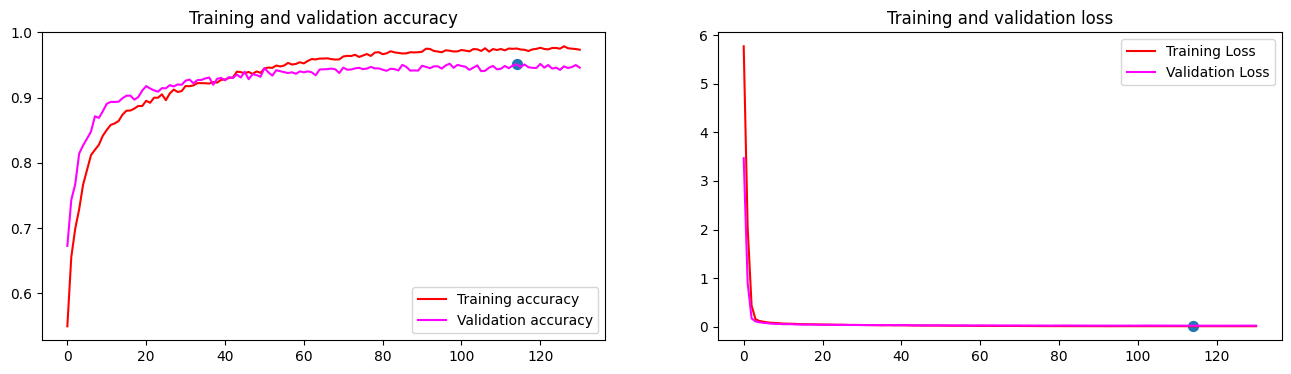

CPU times: user 1h 42min 9s, sys: 8min 5s, total: 1h 50min 15s
Wall time: 51min 22s


In [22]:
%%time

# Train the model
history1 = model.fit(
      train_generator,
      epochs=EPOCHS,
      validation_data=validation_generator,
      callbacks=callbacks,
    )

pd.DataFrame(history1.history).to_csv("history1.csv")
# Plot training results
plot_loss_acc(history1.history)

# Evaluations #1A

Validation Set Stats
model.evaluate
110/110 [==============================] - 3s 22ms/step - loss: 0.0200 - accuracy: 0.9452
model.predict


  0%|          | 0/110 [00:00<?, ?it/s]

Evaluation Metrics

                precision    recall  f1-score   support

  Chinee apple    0.91429   0.85333   0.88276       225
       Lantana    0.94286   0.92958   0.93617       213
   Parkinsonia    0.96618   0.97087   0.96852       206
    Parthenium    0.96552   0.96078   0.96314       204
Prickly acacia    0.92237   0.95283   0.93735       212
   Rubber vine    0.94286   0.98020   0.96117       202
     Siam weed    0.93868   0.92558   0.93208       215
    Snake weed    0.86139   0.85714   0.85926       203
      Negative    0.96665   0.97036   0.96850      1822

      accuracy                        0.95003      3502
     macro avg    0.93564   0.93341   0.93433      3502
  weighted avg    0.94987   0.95003   0.94984      3502


                False Positive Rate  Accuracy
Chinee apple               0.005493  0.853333
Lantana                    0.003649  0.929577
Parkinsonia                0.002124  0.970874
Parthenium                 0.002122  0.960784
Prickly acacia    

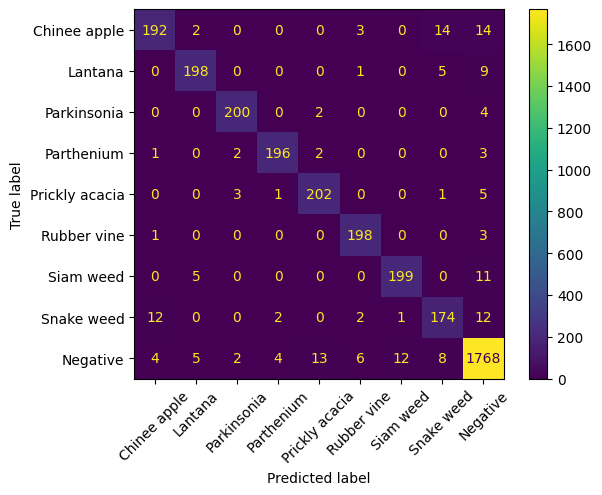

Test Set Stats
model.evaluate
110/110 [==============================] - 3s 24ms/step - loss: 0.6966 - accuracy: 0.4722
model.predict


  0%|          | 0/110 [00:00<?, ?it/s]

Evaluation Metrics

                precision    recall  f1-score   support

  Chinee apple    0.14570   0.09778   0.11702       225
       Lantana    0.13924   0.05164   0.07534       213
   Parkinsonia    0.41935   0.06311   0.10970       206
    Parthenium    0.11765   0.03902   0.05861       205
Prickly acacia    0.20513   0.03756   0.06349       213
   Rubber vine    0.15000   0.04455   0.06870       202
     Siam weed    0.20833   0.04651   0.07605       215
    Snake weed    0.17582   0.07882   0.10884       203
      Negative    0.53031   0.85502   0.65461      1821

      accuracy                        0.47217      3503
     macro avg    0.23239   0.14600   0.14804      3503
  weighted avg    0.36915   0.47217   0.38107      3503


                False Positive Rate  Accuracy
Chinee apple               0.039353  0.097778
Lantana                    0.020669  0.051643
Parkinsonia                0.005460  0.063107
Parthenium                 0.018193  0.039024
Prickly acacia    

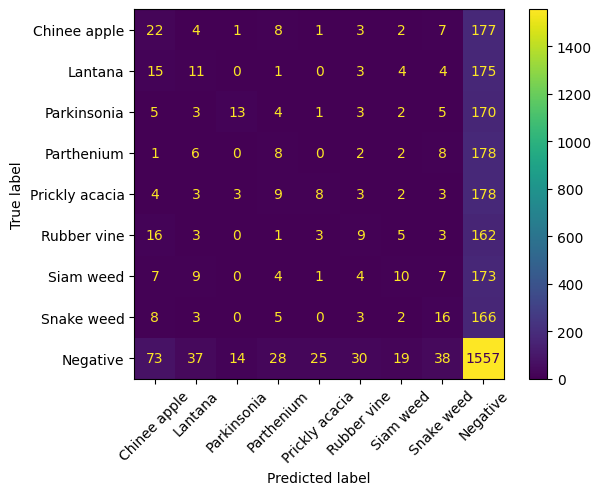

In [23]:
print("Validation Set Stats")        
a, b = eval_model(model, validation_generator)

print("Test Set Stats")   
a, b = eval_model(model, test_generator)

# Freezing Base Model

In [24]:
with strategy.scope():
    for layer in model.layers:
        if 'base' in layer.name.lower():
            print("Freezing layer", layer.name, layer.trainable)
            layer.trainable = False

Freezing layer MobilenetV3small_base_ True


# Evaluations #1B

Train Set Statistics
model.evaluate
329/329 [==============================] - 8s 23ms/step - loss: 0.0035 - accuracy: 0.9929
model.predict


  0%|          | 0/329 [00:00<?, ?it/s]

Evaluation Metrics

                precision    recall  f1-score   support

  Chinee apple    0.99701   0.98817   0.99257       676
       Lantana    1.00000   1.00000   1.00000       637
   Parkinsonia    0.99677   0.99838   0.99758       619
    Parthenium    0.99191   1.00000   0.99594       613
Prickly acacia    0.99369   0.98901   0.99135       637
   Rubber vine    0.99671   1.00000   0.99835       605
     Siam weed    0.99844   0.99224   0.99533       644
    Snake weed    0.98864   0.99836   0.99347       610
      Negative    0.99744   0.99725   0.99735      5463

      accuracy                        0.99648     10504
     macro avg    0.99562   0.99593   0.99577     10504
  weighted avg    0.99648   0.99648   0.99648     10504


                False Positive Rate  Accuracy
Chinee apple               0.000204  0.988166
Lantana                    0.000000  1.000000
Parkinsonia                0.000202  0.998384
Parthenium                 0.000506  1.000000
Prickly acacia    

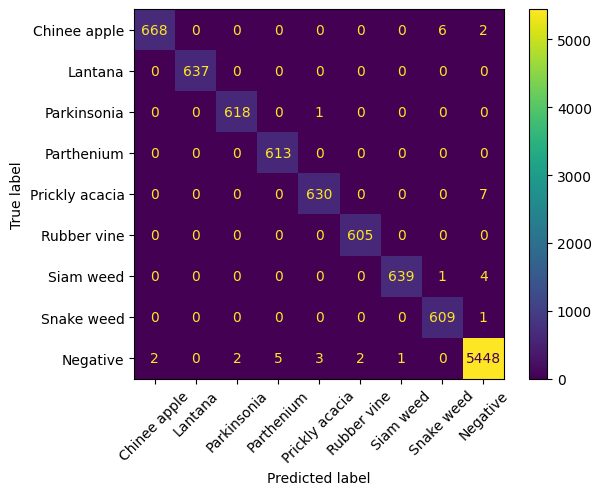

Validation Set Stats
model.evaluate
110/110 [==============================] - 3s 23ms/step - loss: 0.0212 - accuracy: 0.9480
model.predict


  0%|          | 0/110 [00:00<?, ?it/s]

Evaluation Metrics

                precision    recall  f1-score   support

  Chinee apple    0.92537   0.82667   0.87324       225
       Lantana    0.94009   0.95775   0.94884       213
   Parkinsonia    0.98049   0.97573   0.97810       206
    Parthenium    0.91705   0.97549   0.94537       204
Prickly acacia    0.92727   0.96226   0.94444       212
   Rubber vine    0.95169   0.97525   0.96333       202
     Siam weed    0.95775   0.94884   0.95327       215
    Snake weed    0.86321   0.90148   0.88193       203
      Negative    0.97403   0.96762   0.97081      1822

      accuracy                        0.95403      3502
     macro avg    0.93744   0.94345   0.93993      3502
  weighted avg    0.95436   0.95403   0.95390      3502


                False Positive Rate  Accuracy
Chinee apple               0.004577  0.826667
Lantana                    0.003953  0.957746
Parkinsonia                0.001214  0.975728
Parthenium                 0.005458  0.975490
Prickly acacia    

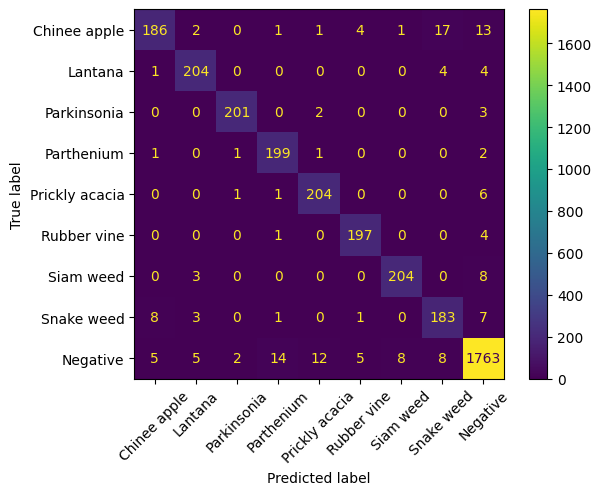

Test Set Stats
model.evaluate
110/110 [==============================] - 3s 22ms/step - loss: 0.6966 - accuracy: 0.4722
model.predict


  0%|          | 0/110 [00:00<?, ?it/s]

Evaluation Metrics

                precision    recall  f1-score   support

  Chinee apple    0.92195   0.84000   0.87907       225
       Lantana    0.93088   0.94836   0.93953       213
   Parkinsonia    0.96618   0.97087   0.96852       206
    Parthenium    0.90950   0.98049   0.94366       205
Prickly acacia    0.96618   0.93897   0.95238       213
   Rubber vine    0.98492   0.97030   0.97756       202
     Siam weed    0.98113   0.96744   0.97424       215
    Snake weed    0.88889   0.90640   0.89756       203
      Negative    0.97046   0.97419   0.97232      1821

      accuracy                        0.95747      3503
     macro avg    0.94668   0.94411   0.94498      3503
  weighted avg    0.95762   0.95747   0.95731      3503


                False Positive Rate  Accuracy
Chinee apple               0.004881  0.840000
Lantana                    0.004559  0.948357
Parkinsonia                0.002123  0.970874
Parthenium                 0.006064  0.980488
Prickly acacia    

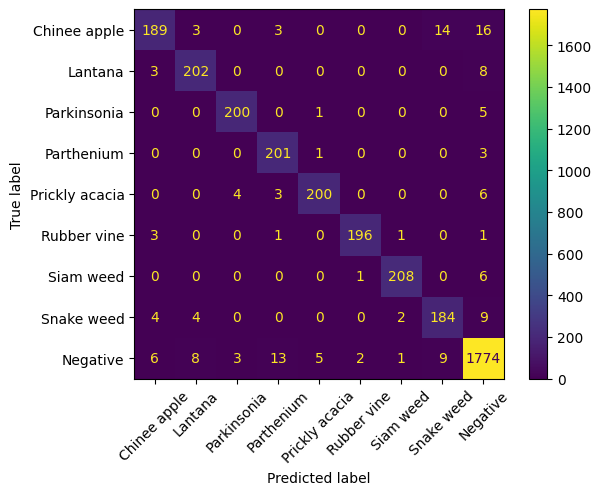

In [25]:
## Test After Freezing
print("Train Set Statistics")
a, b = eval_model(model, train_generator)

print("Validation Set Stats")        
a, b = eval_model(model, validation_generator)
pd.DataFrame({'actual': a, "prediction": [[c.item() for c in n.numpy()] for n in b]}).to_json("Eval1_Validaton.json")

print("Test Set Stats")   
a, b = eval_model(model, test_generator)
pd.DataFrame({'actual': a, "prediction": [[c.item() for c in n.numpy()] for n in b]}).to_json("Eval1_Test.json")

Evaluation Metrics

                precision    recall  f1-score   support

  Chinee apple    0.88158   0.89333   0.88742       225
       Lantana    0.84082   0.96714   0.89956       213
   Parkinsonia    0.96618   0.97087   0.96852       206
    Parthenium    0.90950   0.98049   0.94366       205
Prickly acacia    0.87931   0.95775   0.91685       213
   Rubber vine    0.98990   0.97030   0.98000       202
     Siam weed    0.98122   0.97209   0.97664       215
    Snake weed    0.88889   0.90640   0.89756       203
      Negative    0.98116   0.94399   0.96222      1821

      accuracy                        0.94776      3503
     macro avg    0.92428   0.95137   0.93694      3503
  weighted avg    0.95013   0.94776   0.94829      3503


                False Positive Rate  Accuracy
Chinee apple               0.008237  0.893333
Lantana                    0.011854  0.967136
Parkinsonia                0.002123  0.970874
Parthenium                 0.006064  0.980488
Prickly acacia    

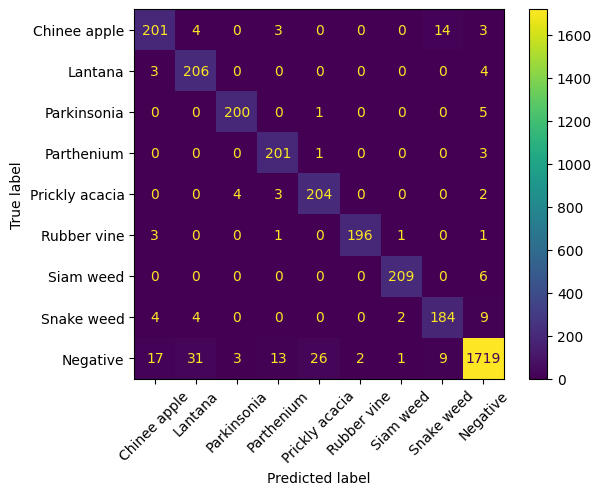

In [26]:
printStats(a,b,0.11)

# Trial 2

In [27]:
with strategy.scope():
    loss = tf.keras.losses.CategoricalFocalCrossentropy()
    optimizer = Adam(learning_rate=INIT_LR2,  weight_decay=W_DECAY2, clipnorm=1.0) if not USE_ADAMW else AdamW(learning_rate=INIT_LR2,  weight_decay=W_DECAY2)
    metrics = [] if isTPU else ['accuracy']
    
    model.compile(loss=loss,
              optimizer=optimizer,
              metrics=metrics)

    reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor=ES_MONITOR, factor=LR_REDUCTION_FACTOR, patience=LR_REDUCTION_PATIENCE, verbose=1, min_lr=MIN_LR2)


print(model.optimizer.get_config())

{'name': 'AdamW', 'weight_decay': 0.0005, 'clipnorm': None, 'global_clipnorm': None, 'clipvalue': None, 'use_ema': False, 'ema_momentum': 0.99, 'ema_overwrite_frequency': None, 'jit_compile': True, 'is_legacy_optimizer': False, 'learning_rate': 2e-06, 'beta_1': 0.9, 'beta_2': 0.999, 'epsilon': 1e-07, 'amsgrad': False}


Epoch 1/300


2025-07-30 22:58:47.793217: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inDeepWeeds-MobilenetV3small_base_/dropout_1/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


329/329 [==============================] - 17s 38ms/step - loss: 0.0160 - accuracy: 0.9479 - val_loss: 0.0190 - val_accuracy: 0.9546 - lr: 2.0000e-06
Epoch 2/300
329/329 [==============================] - 11s 34ms/step - loss: 0.0149 - accuracy: 0.9527 - val_loss: 0.0192 - val_accuracy: 0.9543 - lr: 2.0000e-06
Epoch 3/300
329/329 [==============================] - 12s 35ms/step - loss: 0.0141 - accuracy: 0.9542 - val_loss: 0.0193 - val_accuracy: 0.9546 - lr: 2.0000e-06
Epoch 4/300
328/329 [============================>.] - ETA: 0s - loss: 0.0148 - accuracy: 0.9546
Epoch 4: ReduceLROnPlateau reducing learning rate to 1.5999999959603884e-06.
329/329 [==============================] - 11s 33ms/step - loss: 0.0148 - accuracy: 0.9547 - val_loss: 0.0194 - val_accuracy: 0.9537 - lr: 2.0000e-06
Epoch 5/300
329/329 [==============================] - 11s 34ms/step - loss: 0.0160 - accuracy: 0.9506 - val_loss: 0.0193 - val_accuracy: 0.9540 - lr: 1.6000e-06
Epoch 6/300
329/329 [===================

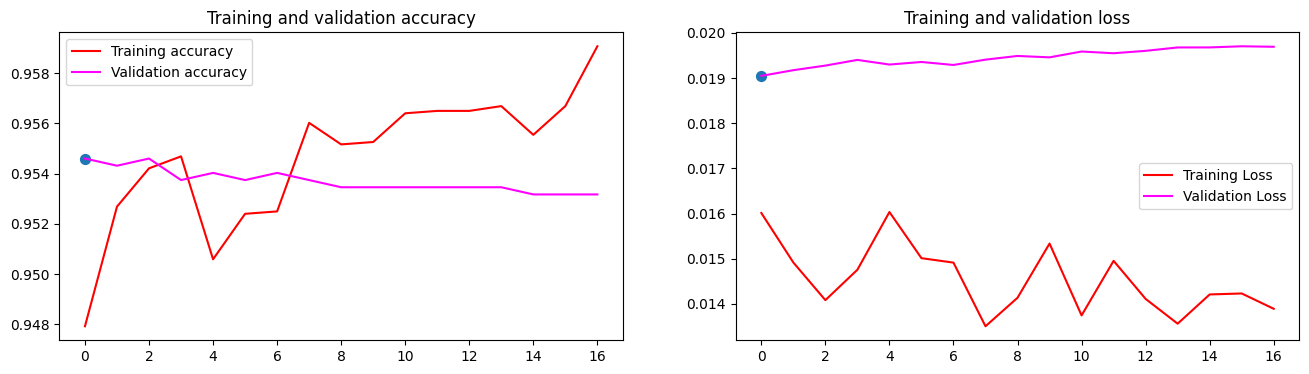

CPU times: user 9min 7s, sys: 55.6 s, total: 10min 3s
Wall time: 3min 24s


In [28]:
%%time

# Train the model
history2 = model.fit(
      train_generator,
      epochs=EPOCHS,
      validation_data=validation_generator,
      callbacks=[early_stopping, reduce_lr]
    )

print("Saving the Checkpoint")
model.save(MODEL_NAME)

pd.DataFrame(history2.history).to_csv("history2.csv")
# Plot training results
plot_loss_acc(history2.history)

# Accuracy / Loss Plots

Total Epochs: range(0, 148)


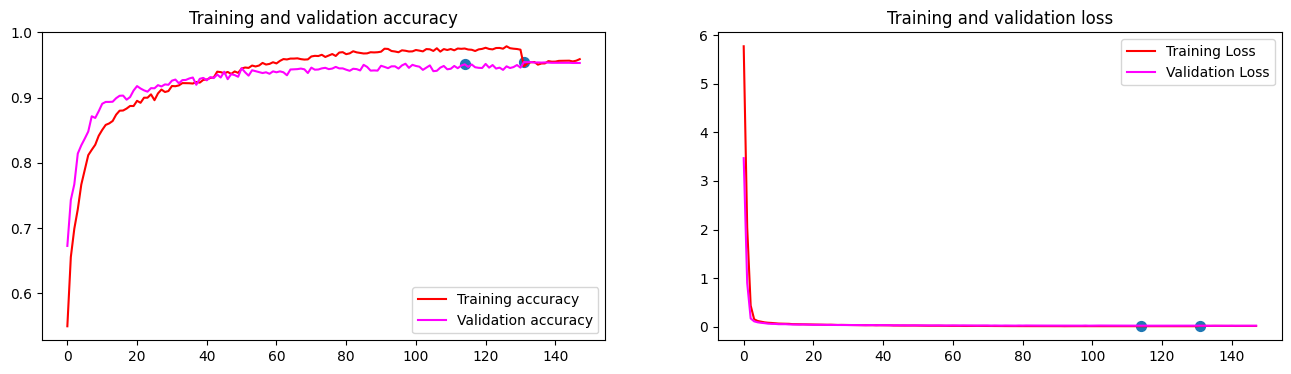

In [29]:
import copy

history = copy.deepcopy(history1.history)

for key in history:
    history[key].extend(history2.history[key])


h1len = len(history1.history['accuracy'])
h2len = len(history2.history['accuracy'])

pat_es = ES_PATIENCE + 1
history['peaks'] = [h1len-pat_es, (h1len+h2len)-pat_es]
history['peaks'] = [i if i>=0 else 0 for i in history['peaks']]

plot_loss_acc(history)

Total Epochs: range(0, 131)


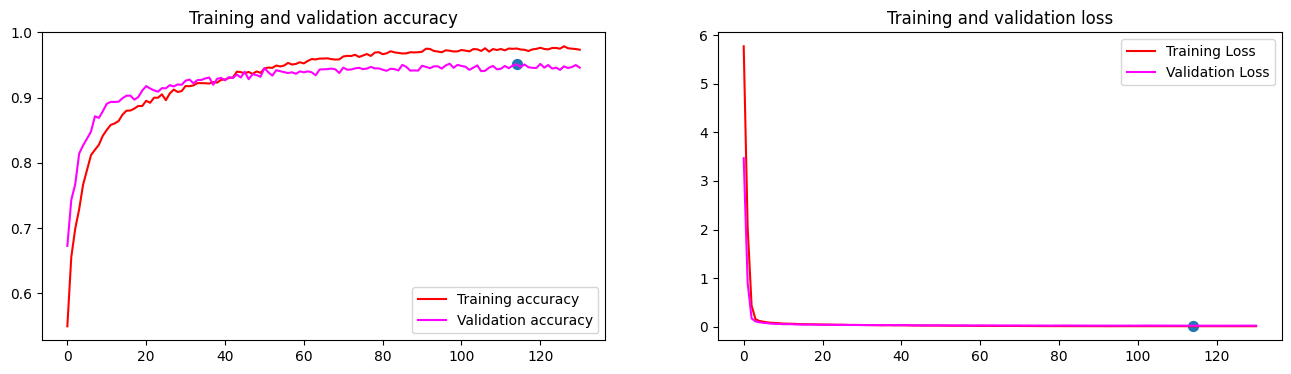

Total Epochs: range(0, 17)


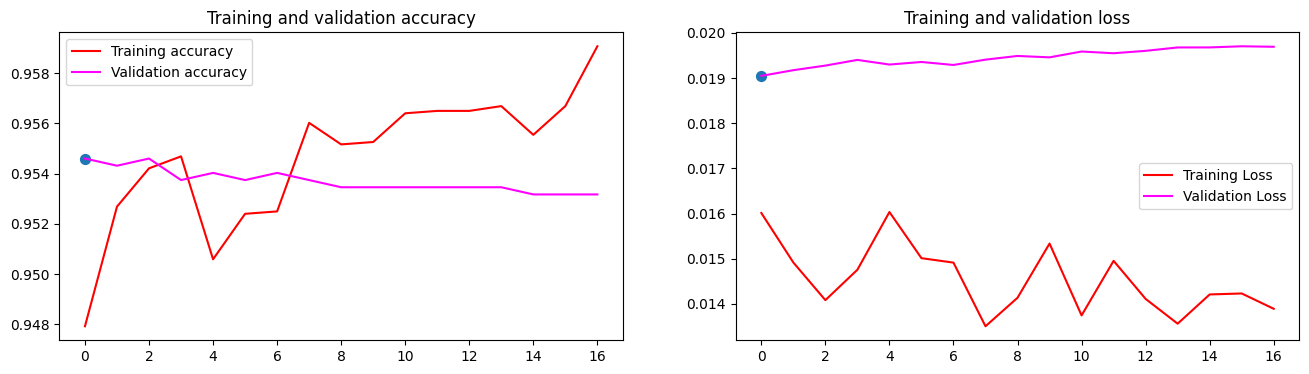

In [30]:
plot_loss_acc(history1.history)
plot_loss_acc(history2.history)

# Evaluation#2

Train Set Statistics
model.evaluate
329/329 [==============================] - 7s 20ms/step - loss: 0.0025 - accuracy: 0.9965
model.predict


  0%|          | 0/329 [00:00<?, ?it/s]

Evaluation Metrics

                precision    recall  f1-score   support

  Chinee apple    0.99405   0.98817   0.99110       676
       Lantana    1.00000   1.00000   1.00000       637
   Parkinsonia    0.99517   0.99838   0.99677       619
    Parthenium    0.99352   1.00000   0.99675       613
Prickly acacia    0.99370   0.99058   0.99214       637
   Rubber vine    0.99671   1.00000   0.99835       605
     Siam weed    0.99844   0.99379   0.99611       644
    Snake weed    0.98864   0.99836   0.99347       610
      Negative    0.99780   0.99689   0.99734      5463

      accuracy                        0.99648     10504
     macro avg    0.99534   0.99624   0.99578     10504
  weighted avg    0.99648   0.99648   0.99648     10504


                False Positive Rate  Accuracy
Chinee apple               0.000407  0.988166
Lantana                    0.000000  1.000000
Parkinsonia                0.000303  0.998384
Parthenium                 0.000404  1.000000
Prickly acacia    

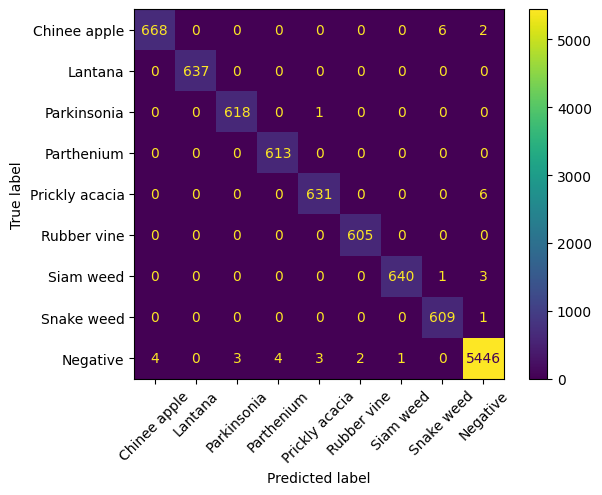


Validation Set Statistics
model.evaluate
110/110 [==============================] - 3s 21ms/step - loss: 0.0190 - accuracy: 0.9546
model.predict


  0%|          | 0/110 [00:00<?, ?it/s]

Evaluation Metrics

                precision    recall  f1-score   support

  Chinee apple    0.93000   0.82667   0.87529       225
       Lantana    0.94419   0.95305   0.94860       213
   Parkinsonia    0.98058   0.98058   0.98058       206
    Parthenium    0.91705   0.97549   0.94537       204
Prickly acacia    0.93151   0.96226   0.94664       212
   Rubber vine    0.95169   0.97525   0.96333       202
     Siam weed    0.95327   0.94884   0.95105       215
    Snake weed    0.86449   0.91133   0.88729       203
      Negative    0.97403   0.96762   0.97081      1822

      accuracy                        0.95460      3502
     macro avg    0.93853   0.94457   0.94100      3502
  weighted avg    0.95497   0.95460   0.95447      3502


                False Positive Rate  Accuracy
Chinee apple               0.004272  0.826667
Lantana                    0.003649  0.953052
Parkinsonia                0.001214  0.980583
Parthenium                 0.005458  0.975490
Prickly acacia    

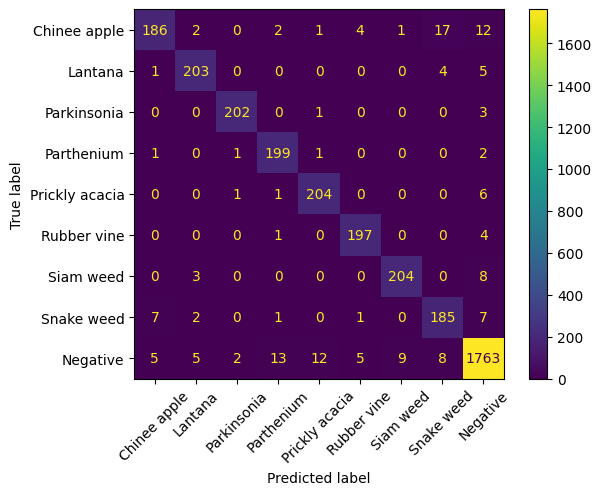


Testn Set Statistics
model.evaluate
110/110 [==============================] - 2s 20ms/step - loss: 0.0176 - accuracy: 0.9580
model.predict


  0%|          | 0/110 [00:00<?, ?it/s]

Evaluation Metrics

                precision    recall  f1-score   support

  Chinee apple    0.92195   0.84000   0.87907       225
       Lantana    0.93088   0.94836   0.93953       213
   Parkinsonia    0.96618   0.97087   0.96852       206
    Parthenium    0.91364   0.98049   0.94588       205
Prickly acacia    0.96618   0.93897   0.95238       213
   Rubber vine    0.98492   0.97030   0.97756       202
     Siam weed    0.98113   0.96744   0.97424       215
    Snake weed    0.88517   0.91133   0.89806       203
      Negative    0.97154   0.97474   0.97314      1821

      accuracy                        0.95804      3503
     macro avg    0.94684   0.94472   0.94538      3503
  weighted avg    0.95821   0.95804   0.95789      3503


                False Positive Rate  Accuracy
Chinee apple               0.004881  0.840000
Lantana                    0.004559  0.948357
Parkinsonia                0.002123  0.970874
Parthenium                 0.005761  0.980488
Prickly acacia    

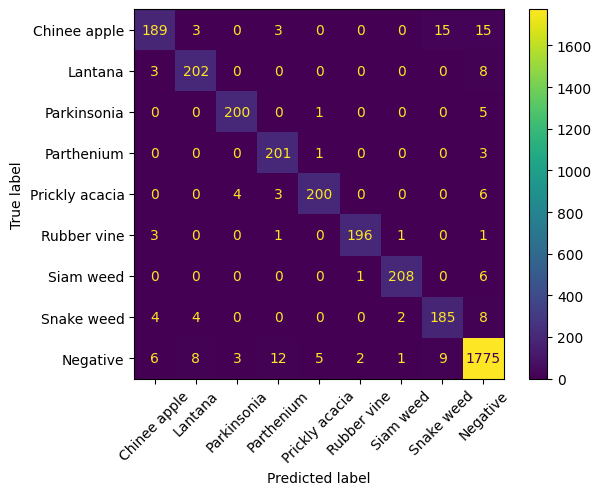

In [31]:
print("Train Set Statistics")
a, b = eval_model(model, train_generator)

print("\nValidation Set Statistics")
a, b = eval_model(model, validation_generator)
pd.DataFrame({'actual': a, "prediction": [[c.item() for c in n.numpy()] for n in b]}).to_json("Eval2_Validaton.json")

print("\nTestn Set Statistics")
a, b = eval_model(model, test_generator)
pd.DataFrame({'actual': a, "prediction": [[c.item() for c in n.numpy()] for n in b]}).to_json("Eval2_Test.json")

Evaluation Metrics

                precision    recall  f1-score   support

  Chinee apple    0.87773   0.89333   0.88546       225
       Lantana    0.84082   0.96714   0.89956       213
   Parkinsonia    0.96618   0.97087   0.96852       206
    Parthenium    0.91364   0.98049   0.94588       205
Prickly acacia    0.87179   0.95775   0.91275       213
   Rubber vine    0.98990   0.97030   0.98000       202
     Siam weed    0.98122   0.97209   0.97664       215
    Snake weed    0.88517   0.91133   0.89806       203
      Negative    0.98227   0.94289   0.96217      1821

      accuracy                        0.94747      3503
     macro avg    0.92319   0.95180   0.93656      3503
  weighted avg    0.95002   0.94747   0.94805      3503


                False Positive Rate  Accuracy
Chinee apple               0.008542  0.893333
Lantana                    0.011854  0.967136
Parkinsonia                0.002123  0.970874
Parthenium                 0.005761  0.980488
Prickly acacia    

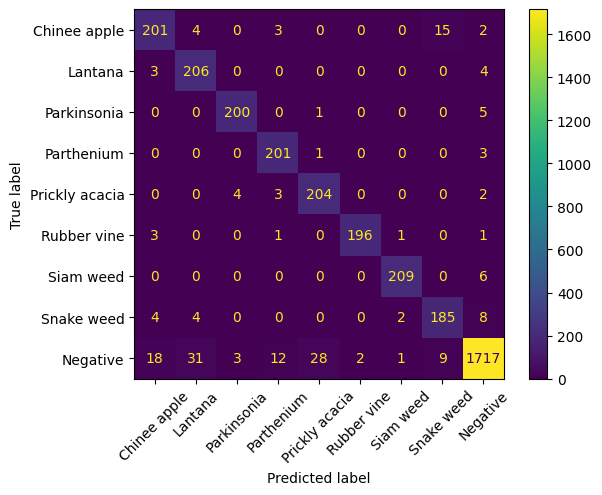

In [32]:
printStats(a,b,0.11)

## Clear Files

In [33]:
shutil.rmtree(base_dir)